In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [11]:
stock_date= yf.download("AAPL", start="2010-1-1")
stock_date.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406480,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303803,6.346312,6.258002,6.338828,477131200
2010-01-08,6.345713,6.346312,6.258302,6.295421,447610800


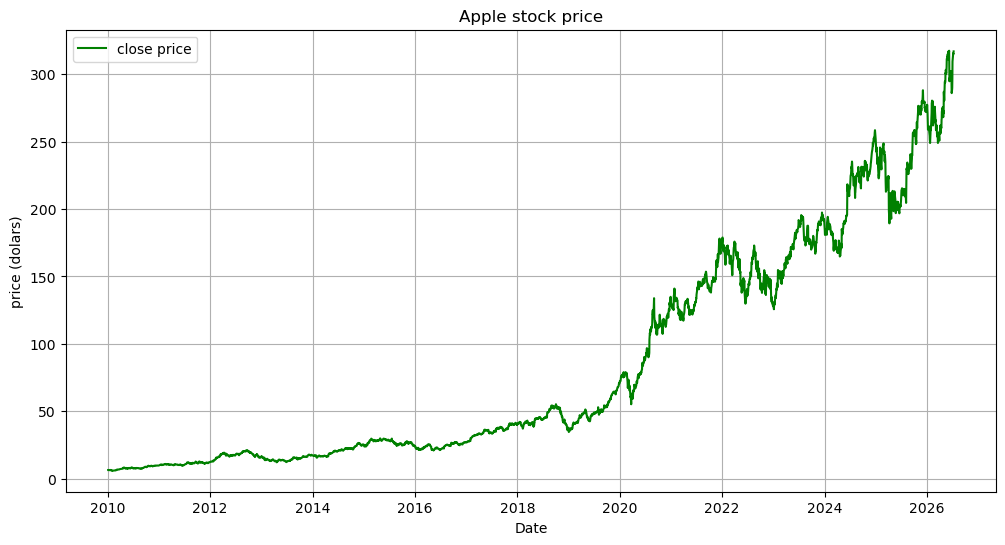

In [20]:
plt.figure(figsize=(12,6))
plt.plot(stock_date.index,stock_date["High"],label="close price",color="green")
plt.title("Apple stock price")
plt.xlabel("Date")
plt.ylabel("price (dolars)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose 

In [15]:
additive_model=seasonal_decompose(stock_date["Close"],model="additive",period=30)

In [17]:
trend_additive=additive_model.trend
seasonal_additive=additive_model.seasonal
noise_additive=additive_model.resid

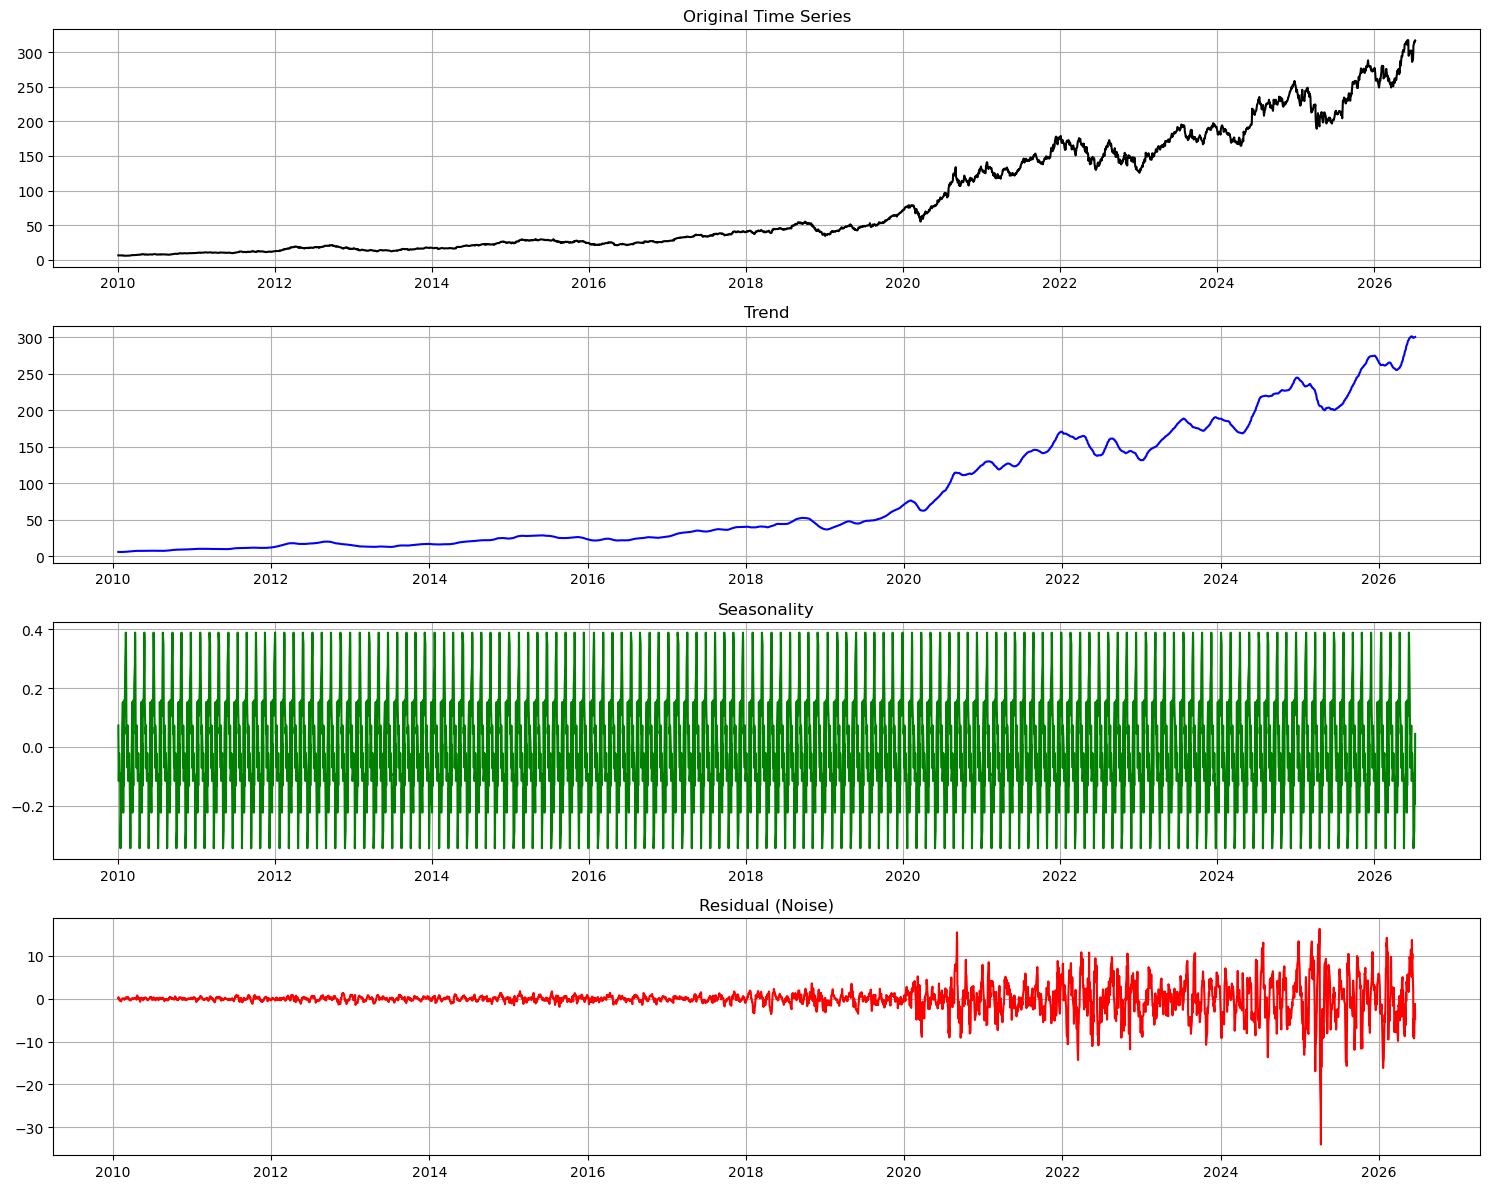

In [21]:
plt.figure(figsize=(15,12))

# Original Data
plt.subplot(4,1,1)
plt.plot(stock_date["High"], color='black')
plt.title("Original Time Series")
plt.grid(True)

# Trend
plt.subplot(4,1,2)
plt.plot(trend_additive, color='blue')
plt.title("Trend")
plt.grid(True)

# Seasonality
plt.subplot(4,1,3)
plt.plot(seasonal_additive, color='green')
plt.title("Seasonality")
plt.grid(True)

# Residual
plt.subplot(4,1,4)
plt.plot(noise_additive, color='red')
plt.title("Residual (Noise)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
from statsmodels.tsa.seasonal import STL 

In [23]:
STL_model=STL(stock_date["Close"],period=30)

In [24]:
result=STL_model.fit()

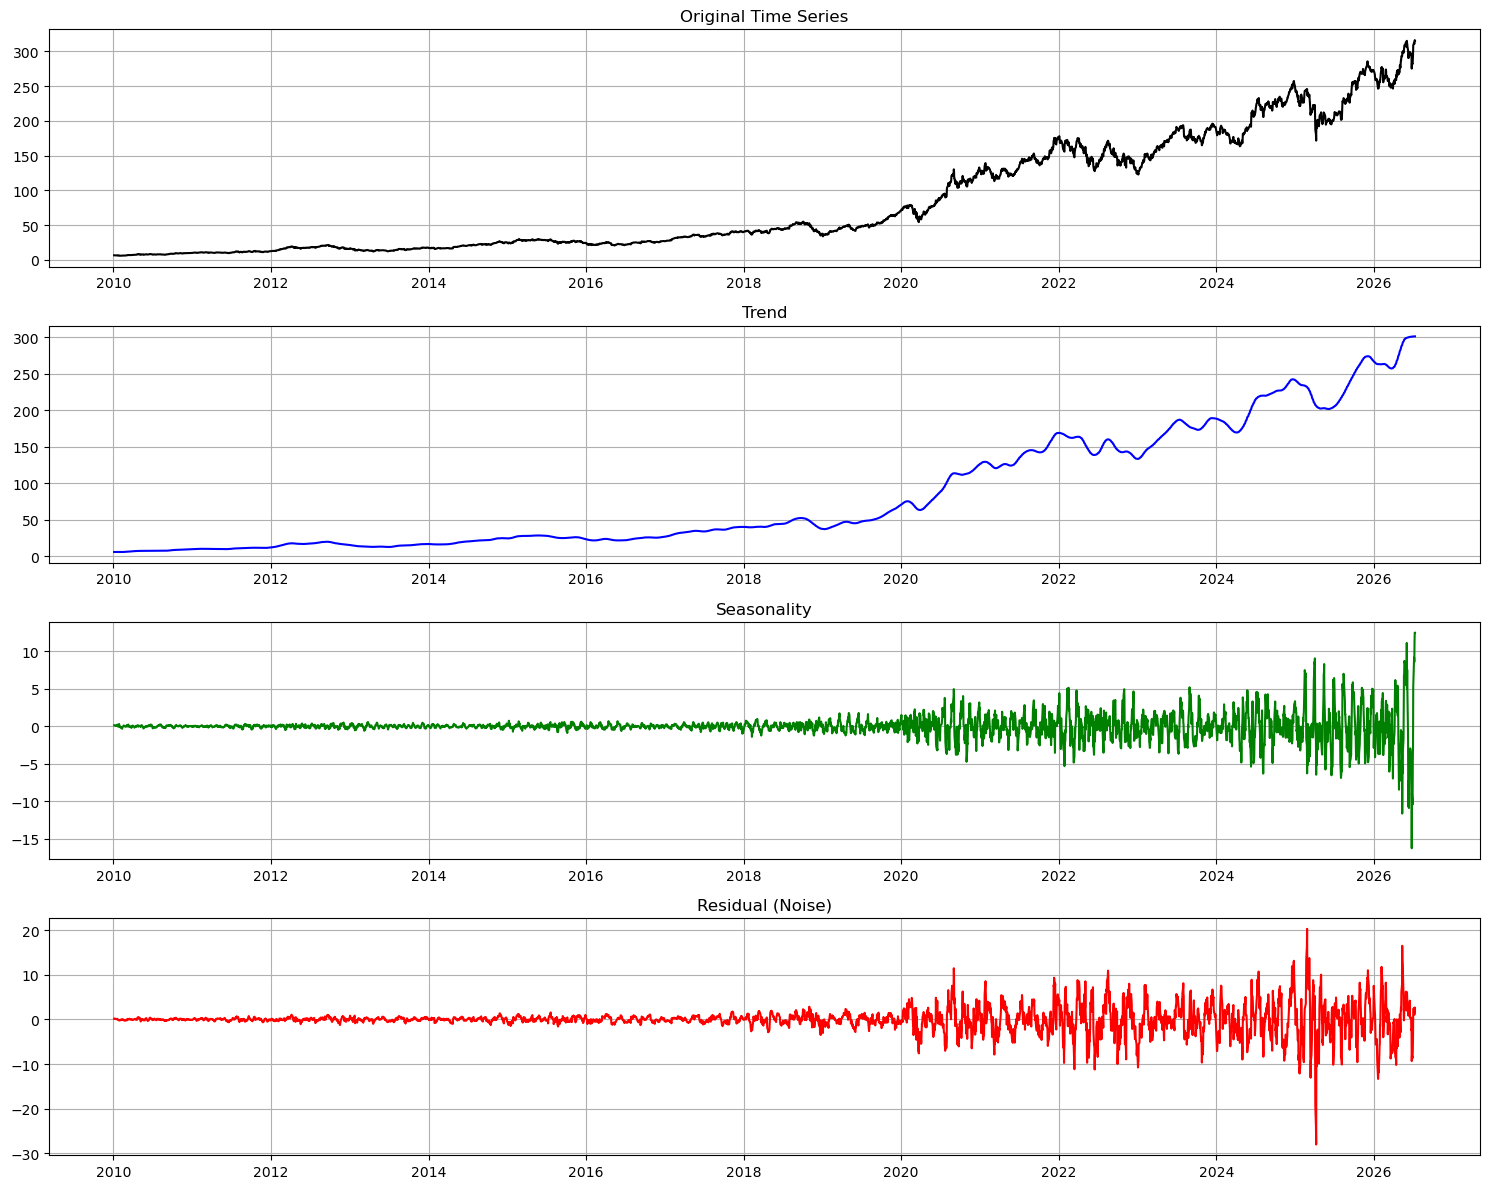

In [25]:
plt.figure(figsize=(15,12))

# Original Data
plt.subplot(4,1,1)
plt.plot(result.observed, color='black')
plt.title("Original Time Series")
plt.grid(True)

# Trend
plt.subplot(4,1,2)
plt.plot(result.trend, color='blue')
plt.title("Trend")
plt.grid(True)

# Seasonality
plt.subplot(4,1,3)
plt.plot(result.seasonal, color='green')
plt.title("Seasonality")
plt.grid(True)

# Residual
plt.subplot(4,1,4)
plt.plot(result.resid, color='red')
plt.title("Residual (Noise)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Stationery Test 

In [27]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(st['Close'].dropna())

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])
print("Number of Observations Used :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is Stationary.")
else:
    print("\nConclusion: The series is NOT Stationary.")

ADF Statistic : 1.7677242663966464
p-value : 0.9982828085133828
Number of Lags Used : 18
Number of Observations Used : 4135

Critical Values:
1% : -3.431932433890647
5% : -2.8622392324749026
10% : -2.567142207816893

Conclusion: The series is NOT Stationary.


# ADF TEST

In [31]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(stock_date['Close'].dropna())

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])
print("Number of Observations Used :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is Stationary.")
else:
    print("\nConclusion: The series is NOT Stationary.")

ADF Statistic : 1.7677242663966464
p-value : 0.9982828085133828
Number of Lags Used : 18
Number of Observations Used : 4135

Critical Values:
1% : -3.431932433890647
5% : -2.8622392324749026
10% : -2.567142207816893

Conclusion: The series is NOT Stationary.


# KPSS TEST

In [28]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS Test
result = kpss(stock_date['Close'].dropna(), regression='c')

print("KPSS Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])

print("\nCritical Values:")
for key, value in result[3].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is NOT Stationary.")
else:
    print("\nConclusion: The series is Stationary.")

KPSS Statistic : 8.921937076968646
p-value : 0.01
Number of Lags Used : 40

Critical Values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739

Conclusion: The series is NOT Stationary.


# KP TEST

In [29]:
# Import the KPSS test function from statsmodels
from statsmodels.tsa.stattools import kpss

# Run the KPSS test on the 'Close' column
# dropna() removes any missing (NaN) values
# regression='c' tests for level stationarity (constant mean)
result = kpss(stock_date['Close'].dropna(), regression='c')

# Print the KPSS test statistic
print("KPSS Statistic :", result[0])

# Print the p-value
print("p-value :", result[1])

# Print the number of lags used in the test
print("Number of Lags Used :", result[2])

# Print the heading for critical values
print("\nCritical Values:")

# Loop through the critical values dictionary
# key = significance level (1%, 5%, 10%, etc.)
# value = corresponding critical value
for key, value in result[3].items():
    print(f"{key} : {value}")

# Check the p-value to determine stationarity
# Null Hypothesis (H0): The series is stationary
if result[1] < 0.05:
    # Reject the null hypothesis
    print("\nConclusion: The series is NOT Stationary.")
else:
    # Fail to reject the null hypothesis
    print("\nConclusion: The series is Stationary.")

KPSS Statistic : 8.921937076968646
p-value : 0.01
Number of Lags Used : 40

Critical Values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739

Conclusion: The series is NOT Stationary.
